# 📝 BlogForge — LangGraph AI Blog Writer

**Course:** QAU LangGraph — Group Project
**Workflow type:** **Iterative + Conditional**

BlogForge is an autonomous multi-agent blog production system. Given a topic it
researches it (live web search), outlines and drafts a full post, injects SEO,
**self-evaluates** with a conditional **retry loop**, and routes through a
**human-review checkpoint** (`interrupt()`) before publishing.

### LangGraph features demonstrated
| # | Feature | Where |
|---|---------|-------|
| 1 | State management (TypedDict + `operator.add` reducer) | `state.py` |
| 2 | 7 meaningful nodes | `nodes.py` |
| 3 | Conditional edges | `quality_check`, `human_review` routing |
| 4 | Loop (retry / human-edit) | `draft → quality_check → draft` |
| 5 | Tool use | DuckDuckGo search + custom SEO scorer (`tools.py`) |
| 6 | Memory / Persistence | `MemorySaver` + `thread_id`, `interrupt()` |
| 7 | Structured output | Pydantic + `with_structured_output()` (`models.py`) |
| 8 | Streamlit interface | `app.py` |


## 1. Setup

Install dependencies (`pip install -r requirements.txt`) and put your Groq API key
in a `.env` file (`GROQ_API_KEY=...`). This notebook runs from the project folder.

In [1]:
from importlib.metadata import version
from dotenv import load_dotenv

load_dotenv()  # loads GROQ_API_KEY from .env
for pkg in ["langgraph", "langchain-core", "langchain-groq", "streamlit", "pydantic"]:
    print(f"{pkg:15}:", version(pkg))

langgraph      : 1.2.4
langchain-core : 1.4.3
langchain-groq : 1.1.3
streamlit      : 1.58.0
pydantic       : 2.13.4


## 2. Architecture

We assemble a `StateGraph` over `BlogState`. The backbone is sequential, but two
conditional branches make it a real agent:

* `quality_check` → **revise** (loop back to `draft`) if the score is below
  threshold and retries remain, else → **human_review**.
* `human_review` → **publish** on approval, or loop back to **draft** if the
  human requests edits.


Nodes: ['research', 'outline', 'draft', 'seo', 'quality_check', 'human_review', 'publish']
Quality threshold: 75 | Max drafts: 3


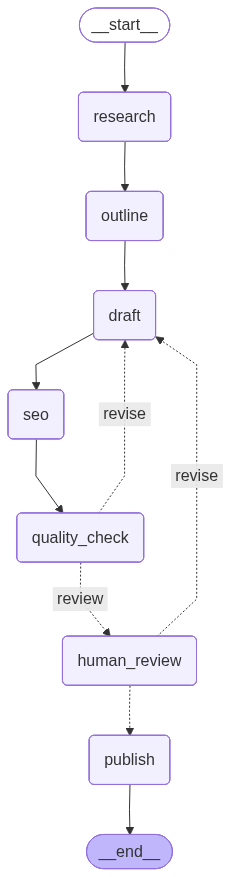

In [2]:
from IPython.display import Image, display
from graph import graph, QUALITY_THRESHOLD, MAX_DRAFTS

print("Nodes:", [n for n in graph.get_graph().nodes if not n.startswith("__")])
print("Quality threshold:", QUALITY_THRESHOLD, "| Max drafts:", MAX_DRAFTS)

# Visualise the graph (assignment requires draw_mermaid_png)
display(Image(graph.get_graph().draw_mermaid_png()))

## 3. Run the agent

We stream the graph on a topic. It runs research → outline → draft → seo →
quality_check, then **pauses at `human_review`** via `interrupt()`. Persistence is
keyed by a `thread_id`.

In [3]:
import uuid
from langgraph.types import Command

config = {"configurable": {"thread_id": str(uuid.uuid4())}}
topic = "How to start composting at home"

for chunk in graph.stream({"topic": topic, "revision_count": 0}, config, stream_mode="updates"):
    for node, update in chunk.items():
        if node == "__interrupt__":
            print("⏸️  INTERRUPT — paused for human review")
        else:
            extra = f" (score={update.get('quality_score')})" if node == "quality_check" else ""
            print(f"✓ {node}{extra}")

✓ research


✓ outline


✓ draft


✓ seo


✓ quality_check (score=82)
⏸️  INTERRUPT — paused for human review


In [4]:
# Inspect the paused state held in the MemorySaver checkpoint
snap = graph.get_state(config)
draft = snap.values["draft"]
print("Paused at        :", snap.next)
print("Quality score    :", snap.values["quality_score"])
print("Revision count   :", snap.values["revision_count"])
print("Draft title      :", draft["title"])
print("Sections         :", len(draft["sections"]))
print("SEO keywords     :", snap.values["seo_output"]["keywords"][:5])
print("SEO scorer result:", snap.values["seo_output"]["report"]["seo_score"])

Paused at        : ('human_review',)
Quality score    : 82
Revision count   : 1
Draft title      : Turning Waste into Wealth: A Beginner's Guide to Composting at Home
Sections         : 7
SEO keywords     : ['composting at home', 'starting a compost pile', 'worm composting', 'vermicomposting', 'compost bin']
SEO scorer result: 48


## 4. Human review → approve

A reviewer can **approve** (→ publish) or **request edits** (loops back to
`draft`). Here we approve to resume the graph from the saved checkpoint — earlier
nodes are *not* re-run.

In [5]:
for chunk in graph.stream(Command(resume={"action": "approve"}), config, stream_mode="updates"):
    for node in chunk:
        print("✓", node)

final = graph.get_state(config)
print("\nFinal status:", final.values["status"])

✓ human_review
✓ publish

Final status: published


In [6]:
from IPython.display import Markdown, display
display(Markdown(graph.get_state(config).values["final_markdown"]))

# Turning Waste into Wealth: A Beginner's Guide to Composting at Home

> Learn how to start composting at home

## Introduction to Composting: Benefits and Basics
Composting at home is a simple and effective way to reduce waste, enrich soil, and lower your carbon footprint. It requires a mix of green and brown materials, proper layering, and can be done through various methods such as worm composting. With the right techniques and materials, anyone can start composting at home and enjoy the numerous benefits it provides.

Composting is a natural process that involves the breakdown of organic materials into a nutrient-rich soil amendment. This process can be done at home, in a backyard or even in small spaces, and can help reduce the amount of waste sent to landfills. By composting, individuals can create a sustainable and environmentally friendly way to manage their waste and improve their soil quality.

The benefits of composting are numerous. It helps to reduce greenhouse gas emissions, conserve water, and create a natural fertilizer for plants. Composting also helps to reduce waste, as it turns organic materials that would otherwise be thrown away into a valuable resource. Additionally, composting can help to improve soil structure, increase crop yields, and support healthy microbial activity.

## Understanding Green and Brown Materials: The Key to a Healthy Compost Pile
A healthy compost pile needs a mix of 'Green' materials (rich in nitrogen) and 'Brown' materials (rich in carbon). Green materials include food scraps, grass clippings, and manure, while brown materials include dried leaves, straw, and shredded newspaper. The ideal ratio of green to brown materials is 2/3 brown materials and 1/3 green materials.

Green materials are high in nitrogen and provide the necessary energy for microbial growth. Brown materials, on the other hand, are high in carbon and provide the necessary structure and aeration for the compost pile. By combining these materials in the right ratio, individuals can create a balanced environment that supports microbial activity and promotes the breakdown of organic materials.

It's also important to note that some materials should not be added to the compost pile. These include meat, dairy, and oils, as they can attract pests and create unpleasant odors. Pet waste and weeds with seeds should also be avoided, as they can contain pathogens and weed seeds that can survive the composting process.

## Setting Up Your Compost: Layering and Maintenance Tips
Layering correctly minimizes pests and odors, making composting at home more pleasant. To set up a compost pile, start with a 4-6 inch layer of brown materials, followed by a 2-3 inch layer of green materials. Repeat this process, ending with a layer of brown materials on top.

Alternate green and brown materials to create a balanced environment for microbial activity. This will help to promote the breakdown of organic materials and reduce the risk of pests and odors. It's also important to maintain the right moisture level, keeping the compost pile moist but not waterlogged.

Regular maintenance is also necessary to ensure the compost pile is working effectively. This includes turning the pile every week or two, adding water as needed, and monitoring the temperature. The ideal temperature for composting is between 130-140°F, which indicates that the microbial activity is high and the breakdown of organic materials is occurring.

## Worm Composting 101: A Fun and Easy Method for Beginners
Worm composting, or vermicomposting, is a fun and effective way to compost at home, especially for beginners. This method involves using red wiggler worms to break down food scraps and other organic materials into a nutrient-rich compost.

To get started with worm composting, individuals will need a worm bin, bedding material, and red wiggler worms. The worm bin can be purchased or made at home using a plastic container or wooden box. Bedding material, such as coconut coir or shredded newspaper, is added to the bin to provide a comfortable environment for the worms.

Food scraps and other organic materials are then added to the bin, and the worms get to work breaking them down. The resulting compost is a nutrient-rich soil amendment that can be used to fertilize plants and improve soil structure.

## Common Mistakes to Avoid: Troubleshooting Your Compost Pile
Composting can be a trial-and-error process, and there are several common mistakes that individuals can make. One of the most common mistakes is adding too many green materials, which can create a pile that is too wet and odorous.

Another common mistake is not maintaining the right moisture level. If the compost pile is too dry, microbial activity will slow down, and the breakdown of organic materials will be incomplete. On the other hand, if the pile is too wet, it can become anaerobic and produce unpleasant odors.

To troubleshoot a compost pile, individuals can start by checking the moisture level and adjusting it as needed. They can also add more brown materials to balance out the green materials and promote microbial activity. Regular turning and monitoring of the temperature can also help to identify and fix any issues with the compost pile.

## Composting in Small Spaces: Tips and Tricks for Urban Gardeners
Composting reduces waste, enriches soil, and lowers your carbon footprint, even in small spaces. Urban gardeners can compost using a variety of methods, including worm composting, bokashi composting, and indoor composting bins.

One of the key challenges of composting in small spaces is managing odors and pests. To minimize these issues, individuals can use a compost bin with a lid or a worm composting system. They can also add a layer of brown materials on top of the compost pile to absorb any odors and reduce the risk of pests.

Another challenge of composting in small spaces is finding enough space for a compost pile. To overcome this challenge, individuals can use a compact compost bin or a vertical composting system. They can also compost in small batches, using a bucket or bin to collect food scraps and other organic materials.

## Conclusion: Starting Your Composting Journey and Enjoying the Rewards
Starting a composting journey can be a rewarding and enriching experience. By following the tips and guidelines outlined in this guide, individuals can create a healthy and thriving compost pile that provides a nutrient-rich soil amendment for their plants.

Composting is a simple and effective way to reduce waste, enrich soil, and lower your carbon footprint. It's a great way to get involved in sustainable living and make a positive impact on the environment. Whether you're a seasoned gardener or a beginner, composting is a fun and rewarding hobby that can bring numerous benefits to your garden and the environment.

So why not get started today? With a little patience and practice, you can create a thriving compost pile and enjoy the many rewards that come with it.

---
**Keywords:** composting at home, starting a compost pile, worm composting, vermicomposting, compost bin, composting for beginners, home composting, composting tips, compost guide

**Slug:** `composting-at-home-a-beginners-guide`


## 5. Try the loop (optional)

Re-run section 3 with a fresh `thread_id`, then resume with
`Command(resume={"action": "edit", "feedback": "Add a section on common mistakes."})`
to watch the graph loop back through `draft → seo → quality_check → human_review`.

Or launch the full UI:

```bash
streamlit run app.py
```
